<a href="https://colab.research.google.com/github/aWolander/google-colab/blob/main/Federated%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from __future__ import annotations
import copy
import torch
import time
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt
import random
import numpy as np
import math
try:
    device = torch.accelerator.current_accelerator().type if \
    torch.accelerator.is_available() else "cpu" # i get an error when i run this locally
except:
    device="cpu"

transform = Compose([
    ToTensor(),
    Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
]) # https://github.com/facebookresearch/dino/blob/7c446df5b9f45747937fb0d72314eb9f7b66930a/eval_image_retrieval.py#L106

CIFAR100 = datasets.CIFAR100(
  root="data",
  download=True,
  transform=transform
)


Client 0: Classes = 10, Mean = 346.60, Std = 8.21
Client 1: Classes = 10, Mean = 342.60, Std = 10.46
Client 2: Classes = 10, Mean = 348.20, Std = 7.91
Client 3: Classes = 10, Mean = 353.00, Std = 6.62
Client 4: Classes = 10, Mean = 352.80, Std = 8.83


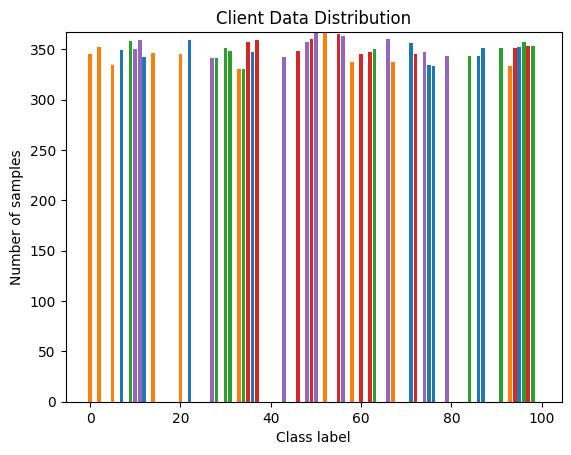

In [2]:
def main() -> None:
    """
    Loads CIFAR-100 dataset and splits it into training, validation, and test sets.
    Then performs an IID client split and tests the data distribution.
    """
    K = 5  # number of clients
    N = 10
    CIFAR100 = datasets.CIFAR100(
        root="data",
        download=True,
        transform=ToTensor()
    )

    train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(
        CIFAR100, [0.7, 0.15, 0.15]
    )

    client_datasets = split_data_non_iid(train_dataset, K, N)
    test_split(client_datasets)


def create_label_indexing(dataset: Dataset) -> dict[int, list[int]]:
    """
    Creates a dictionary mapping each class label to the list of indices where it appears.

    Args:
        dataset: Dataset object (e.g. CIFAR100 or Subset).

    Returns:
        A dictionary mapping label -> list of indices.
    """
    label_index = {i: [] for i in range(100)}
    for idx, (_, label) in enumerate(dataset):
        label_index[label].append(idx)
    return label_index


def split_data_non_iid(dataset: Dataset, K: int, N_c: int) -> list[Subset]:
    """
    Splits the dataset into K non-IID subsets based on label distribution.

    Args:
        dataset: PyTorch dataset.
        K: Number of clients.
        N_c: Number of labels per client.

    Returns:
        List of K Subsets representing client datasets.
    """
    assert K*N_c <= 100, "Too many splits requested"
    index_split = [[] for _ in range(K)]
    label_index = create_label_indexing(dataset)
    unused_labels = set(range(100))
    available_labels = {}

    for client in range(K):
        client_labels = random.sample(list(unused_labels), N_c)
        available_labels[client] = client_labels
        unused_labels -= set(client_labels)

    labels_exhausted = [False] * K

    while not all(labels_exhausted):
        for client in range(K):
            if not available_labels[client]:
                labels_exhausted[client] = True
                continue
            for label in available_labels[client][:]:
                if not label_index[label]:
                    available_labels[client].remove(label)
                    continue
                index_split[client].append(label_index[label].pop())

    for indices in index_split:
        random.shuffle(indices)

    return [Subset(dataset, indices) for indices in index_split]


def split(l: list[int], n: int) -> list[list[int]]:
    """
    Splits a list into n parts in a round-robin fashion.

    Args:
        l: List to split.
        n: Number of splits.

    Returns:
        A list of n sublists.
    """
    return [l[i::n] for i in range(n)]


def split_data_iid(dataset: Dataset, K: int) -> list[Subset]:
    """
    Splits the dataset IID among K clients.

    Args:
        dataset: PyTorch dataset.
        K: Number of clients.

    Returns:
        List of K Subsets representing IID client datasets.
    """
    index_split = [[] for _ in range(K)]
    label_index = create_label_indexing(dataset)

    for label in range(100):
        split_indices = split(label_index[label], K)
        for client in range(K):
            index_split[client] += split_indices[client]

    for indices in index_split:
        random.shuffle(indices)

    return [Subset(dataset, indices) for indices in index_split]


def test_split(client_datasets: list[Subset]) -> None:
    """
    Plots the label distribution across client datasets.

    Args:
        client_datasets: List of Subsets, each representing a client.

    Returns:
        None
    """
    bottom = np.zeros(100)

    for client_id, dataset in enumerate(client_datasets):
        occurrences = np.zeros(100)
        for _, label in dataset:
            occurrences[label] += 1

        non_zero = occurrences[occurrences > 0]
        print(
            f"Client {client_id}: "
            f"Classes = {np.count_nonzero(occurrences)}, "
            f"Mean = {non_zero.mean():.2f}, Std = {non_zero.std():.2f}"
        )

        plt.bar(range(100), occurrences, bottom=bottom, label=f"Client {client_id}")
        bottom += occurrences

    plt.xlabel("Class label")
    plt.ylabel("Number of samples")
    plt.title("Client Data Distribution")
    plt.show()

if "__main__" == __name__:
    main()



In [3]:
'''This is done seperately so that saving and loading the models does not grant
a different dataset. A bit annoying to have to change K here but what can you do'''
K=5
N_c = 20

train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(CIFAR100, [0.7,0.15,0.15])

split_dataset_iid = split_data_iid(train_dataset, K)
split_dataset_non_iid = split_data_non_iid(train_dataset, K, N_c)
split_train_dataloader_iid = [DataLoader(subset, batch_size=100) for subset in split_dataset_iid]
split_train_dataloader_non_iid = [DataLoader(subset, batch_size=100) for subset in split_dataset_non_iid]


train_dataloader = DataLoader(train_dataset, batch_size=100)
test_dataloader = DataLoader(test_dataset, batch_size=100)
validate_dataloader = DataLoader(validate_dataset, batch_size=100)

In [39]:
#import logging

#logging.basicConfig(level=logging.INFO)
#logger = logging.getLogger(__name__)

class DinoFullModel(nn.Module):
    """
    A wrapper around the DINO ViT-S/16 model.
    Adds a custom classification head and includes training and evaluation utilities.
    """

    def __init__(self, learning_rate: float = 1e-3, epochs: int = 20, filepath: str|None = None) -> None:
        """
        Initializes the model with a DINO backbone and custom classification head.

        Args:
            learning_rate (float): Learning rate for optimizer.
            epochs (int): Number of training epochs.
        """
        super().__init__()

        self.learning_rate = learning_rate
        self.epochs = epochs

        # Load pretrained DINO model
        self.backbone = torch.hub.load('facebookresearch/dino:main', 'dino_vits16').to(device)
        self.freeze_backbone()
        # Replace head with a new classifier for CIFAR
        self.backbone.head = nn.Linear(self.backbone.embed_dim, 100)

        # self.backbone.head = nn.Sequential( # apparantly not necessary
        #     nn.Linear(self.backbone.embed_dim, 256),
        #     nn.ReLU(inplace=True),
        #     nn.Dropout(0.5),
        #     nn.Linear(256, 128),
        #     nn.ReLU(inplace=True),
        #     nn.Dropout(0.5),
        #     nn.Linear(128, 100)
        # ).to(device)

        # Loss and optimizer
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.epochs)

        # For gradient masking
        self.scores = []
        self.batched_scores = []
        self.rounds = 1

        # Performance tracking
        self.training_loss_history = []
        self.training_accuracy_history = []
        self.validate_loss_history = []
        self.validate_accuracy_history = []

        # For saving and Loading
        self.current_epoch = 1
        self.loss = None
        if filepath:
            self.load_model(filepath)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone.head(self.backbone(x))

    def train_model(self, dataloader: DataLoader, validate_dataloader: DataLoader|None = None, filepath: str|False=False) -> None:
        """
        Trains the model with optional validation and checkpointing.
        """
        self.train()
        running_loss, total_correct, total_samples = 0.0, 0, 0
        dataset_size = len(dataloader.dataset)

        for epoch in range(self.current_epoch, self.epochs+1):
            print(f"Epoch {epoch}/{self.epochs}")
            running_loss, total_correct, total_samples = 0.0, 0, 0

            for X, y in dataloader:
                X, y = X.to(device), y.to(device)

                outputs = self(X)
                self.loss = self.loss_fn(outputs, y)

                self.loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()

                running_loss += self.loss.item() * X.size(0)
                total_correct += (outputs.argmax(dim=1) == y).sum().item()
                total_samples += X.size(0)
                if total_samples%5000 == 0:
                    print(f"Samples processed: {total_samples} out of {dataset_size}" )

            epoch_loss = running_loss / total_samples
            epoch_acc = total_correct / total_samples
            self.training_loss_history.append(epoch_loss)
            self.training_accuracy_history.append(epoch_acc)

            print(f"Train Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

            if validate_dataloader:
                val_loss, val_acc = self.test_model(validate_dataloader)
                self.validate_loss_history.append(val_loss)
                self.validate_accuracy_history.append(val_acc)
                print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

            self.scheduler.step()
            self.current_epoch = epoch
            if filepath:
                self.save_model(filepath)

    def finetune(self, \
                 dataloader: DataLoader,sparsity: float, \
                 validate_dataloader: DataLoader|None=None, \
                 use_batched: True|False = False, \
                 use_both_scoring_methods: True|False = False) -> None:
        '''
        https://arxiv.org/pdf/2504.02620
        '''
        self.freeze_head()
        self.unfreeze_backbone()
        self.train()
        if sparsity < 1.0:
            for round in range(self.rounds):
                print(f"Training round {round+1}/{self.rounds}")
                sparseness = sparsity ** (round/self.rounds)
                self.score_parameters(dataloader, use_batched = use_batched, \
                                      use_both_scoring_methods=use_both_scoring_methods)
                print("Scoring complete, creating mask.")
                self.create_mask(sparseness)
        print("Performing backprop for finetuning")

        self.train_model(dataloader, validate_dataloader)
        self.freeze_backbone()
        self.unfreeze_head()

    def score_parameters(self, dataloader: DataLoader,
                     use_batched: True|False = False,
                     use_both_scoring_methods: True|False = False) -> None:
        self.backbone.eval()
        self.scores = []
        self.batched_scores = []
        for parameter in self.backbone.parameters(recurse=True):
            self.scores.append(torch.zeros_like(parameter))
            self.batched_scores.append(torch.zeros_like(parameter))
        total_samples = 0
        dataset_size = len(dataloader.dataset)

        batched_time = 0.0
        unbatched_time = 0.0

        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            total_samples += X.size(0)
            logits = self.backbone(X)
            outdx = torch.distributions.Categorical(logits=logits).sample().unsqueeze(1).detach()
            samples = torch.gather(logits, 1, outdx)

            # Batched scoring
            if use_batched or use_both_scoring_methods:
                start_time = time.time()
                loss = samples.mean()
                self.zero_grad()
                loss.backward(retain_graph=True)
                for parameter, batched_parameter_score in zip(self.backbone.parameters(recurse=True), self.batched_scores):
                    if parameter.grad is not None:
                        batched_parameter_score += parameter.grad.data.pow(2).detach().clone()
                batched_time += time.time() - start_time

            # Unbatched scoring
            if not use_batched or use_both_scoring_methods:
                start_time = time.time()
                for datapoint_index in range(X.size(0)):
                    self.zero_grad()
                    torch.autograd.backward(samples[datapoint_index], retain_graph=True)
                    for parameter, parameter_score in zip(self.backbone.parameters(recurse=True), self.scores):
                        if parameter.grad is not None:
                            parameter_score += parameter.grad.data.pow(2).detach().clone()
                unbatched_time += time.time() - start_time

            if total_samples % 5000 == 0:
                print(f"Samples processed: {total_samples} / {dataset_size}")
                if use_batched or use_both_scoring_methods:
                    print(f"Batched scoring time so far:   {batched_time:.4f} seconds")
                if not use_batched or use_both_scoring_methods:
                    print(f"Unbatched scoring time so far: {unbatched_time:.4f} seconds")
                if use_both_scoring_methods:
                    print(f"Time difference so far:        {unbatched_time - batched_time:.4f} seconds")

        print("\n--- Final Timing Results ---")
        if use_batched or use_both_scoring_methods:
            print(f"Total batched scoring time:   {batched_time:.4f} seconds")
        if not use_batched or use_both_scoring_methods:
            print(f"Total unbatched scoring time: {unbatched_time:.4f} seconds")
        if use_both_scoring_methods:
            print(f"Overall time difference:      {unbatched_time - batched_time:.4f} seconds")

    def create_mask(self, sparseness):
        flattened_score_vector = torch.cat([score_tensor.flatten() for score_tensor in self.scores], dim=0)
        total_parameters = len(flattened_score_vector)
        p = math.floor(sparseness*total_parameters)
        threshold_value = flattened_score_vector.sort(descending=True).values[p-1]
        for parameter in self.backbone.parameters(recurse = True):
            # <= or >???
            parameter[parameter >= threshold_value].detach()

    def test_model(self, dataloader: DataLoader) -> tuple[float, float]:
        """
        Evaluates the model on a test/validation dataloader.
        """
        self.eval()
        total_loss, total_correct, total_samples = 0.0, 0, 0

        with torch.no_grad():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
                outputs = self(X)
                loss = self.loss_fn(outputs, y)

                total_loss += loss.item() * X.size(0)
                total_correct += (outputs.argmax(dim=1) == y).sum().item()
                total_samples += X.size(0)

        return total_loss / total_samples, total_correct / total_samples

    def save_model(self, filepath: str) -> None:
        """
        Saves model weights and optimizer state.

        Args:
            filepath (str): Path to save the checkpoint.
        """
        torch.save({
            'epoch': self.current_epoch+1,
            'model_state_dict': self.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'training_loss_history': self.training_loss_history,
            'training_accuracy_history': self.training_accuracy_history,
            'validate_loss_history': self.validate_loss_history,
            'validate_accuracy_history': self.validate_accuracy_history

        }, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath: str) -> None:
        """
        Loads model weights and optimizer state from a checkpoint.

        Args:
            filepath (str): Path to the saved checkpoint.
        """
        checkpoint = torch.load(filepath, map_location=device)
        self.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.current_epoch = checkpoint['epoch']
        self.training_loss_history = checkpoint['training_loss_history']
        self.training_accuracy_history = checkpoint['training_accuracy_history']
        self.validate_loss_history = checkpoint['validate_loss_history']
        self.validate_accuracy_history = checkpoint['validate_accuracy_history']
        print(f"Model loaded from {filepath}")

    def plot_performance(self) -> None:
        """
        Plots training and validation loss and accuracy curves.
        """
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        if self.training_loss_history:
          axs[0].plot(self.training_loss_history, label='Train Loss')
        if self.validate_loss_history:
            axs[0].plot(self.validate_loss_history, label='Val Loss')
        axs[0].set_title('Loss')
        axs[0].legend()
        axs[0].grid(True)
        if self.training_accuracy_history:
          axs[1].plot(self.training_accuracy_history, label='Train Accuracy')
        if self.validate_accuracy_history:
            axs[1].plot(self.validate_accuracy_history, label='Val Accuracy')
        axs[1].set_title('Accuracy')
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_score_heatmaps(self, show_difference: bool = True, max_tensors: int = 5):
        """
        Plots heatmaps comparing unbatched and batched gradient score matrices.

        Args:
            show_difference (bool): Whether to include heatmap of the difference.
            max_params (int): Maximum number of parameter tensors to visualize.
        """
        num_params = min(len(self.scores), len(self.batched_scores), max_tensors)
        ncols = 3 if show_difference else 2
        fig, axes = plt.subplots(num_params, ncols, figsize=(5 * ncols, 4 * num_params))

        for idx in range(num_params):
            unbatched = self.scores[idx].cpu()
            batched = self.batched_scores[idx].cpu()

            unbatched = unbatched.view(unbatched.size(0), -1)
            batched = batched.view(batched.size(0), -1)
            difference = unbatched - batched

            # Plot unbatched
            ax = axes[idx][0] if show_difference else axes[idx][0]
            im = ax.imshow(unbatched, aspect='auto', cmap='viridis')
            ax.set_title(f"Param {idx} - Unbatched")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # Plot batched
            ax = axes[idx][1] if show_difference else axes[idx][1]
            im = ax.imshow(batched, aspect='auto', cmap='viridis')
            ax.set_title(f"Param {idx} - Batched")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # Plot difference
            if show_difference:
                ax = axes[idx][2]
                im = ax.imshow(difference.abs(), aspect='auto', cmap='magma')
                ax.set_title(f"Param {idx} - |Difference|")
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def freeze_head(self):
        for param in self.backbone.head.parameters():
            param.requires_grad = False

    def unfreeze_head(self):
        for param in self.backbone.head.parameters():
            param.requires_grad = True



In [10]:
class FL_client(DinoFullModel):
    '''
    Basically just the single model, but with addition and scaling functionality.
    To facilitate FedAvg more easily.
    '''
    def __init__(self, epochs:int=0) -> None:
        super().__init__(epochs=epochs)

    def __add__(self, other: FL_client) -> FL_client:
        assert isinstance(other, FL_client)
        temp_client = FL_client().to(device) # there has to be a better way
        temp_client.load_state_dict(self.state_dict())
        with torch.no_grad():
            for (name, param), (_, other_param) in zip(temp_client.named_parameters(), other.named_parameters()):
                param.copy_(param + other_param.to(device))
        return temp_client

    def __mul__(self, multiplier: float|int) -> FL_client:
        assert isinstance(multiplier, float|int)
        temp_client = FL_client().to(device)
        temp_client.load_state_dict(self.state_dict())
        with torch.no_grad():
                for name, param in temp_client.named_parameters():
                    param.copy_(param * multiplier)
        return temp_client

    def __rmul__(self, multiplier: float|int) -> FL_client:
        return self.__mul__(multiplier)

    def __sub__(self, other: FL_client) -> FL_client:
        assert isinstance(other, FL_client)
        return self + (-other)

    def __truediv__(self, divisor: float|int) -> FL_client:
        return self.__mul__(1/divisor)

class FL_server():
    def __init__(self, K: int, filepath:str|None = None) -> None:
        self.model = DinoFullModel().to(device)

        self.K = K
        self.training_rounds = 10
        self.client_epochs = 5

        self.current_training_round = 1

        self.loss_fn = nn.CrossEntropyLoss()
        self.clients = []
        for i in range(self.K):
            temp_client = FL_client()
            temp_client.epochs = 0
            self.clients.append(temp_client) # pointers? should be fine

        if filepath:
            self.load_model(filepath)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def FedAvg(self, dataloaders_list: list[DataLoader],C: float, validate_dataloader: DataLoader|None = None, filepath: str|None = None) -> None:
        for training_round in range(self.current_training_round, self.training_rounds+1):
            print(f"----------- TRAINING ROUND {training_round}. -----------")
            m = max(C*self.K, 1)
            rand_set_clients = random.sample(range(self.K), m)
            client_model_sum = None
            m_t = 0
            for client_id in rand_set_clients:
                temp_client = self.clients[client_id]
                temp_client.epochs = self.client_epochs*self.current_training_round
                temp_loader = dataloaders_list[client_id]

                print(f"----------- TRAIN LOOP FOR CLIENT {client_id}. -----------")
                temp_client.train_model(temp_loader)
                n_k = len(temp_loader.dataset)
                m_t += n_k
                # Easier than instantiating an empty model
                if client_model_sum is None:
                    client_model_sum = n_k*temp_client
                else:
                    client_model_sum = client_model_sum + n_k*temp_client

            client_model_sum = (1/m_t) * client_model_sum
            self.model.backbone = client_model_sum.backbone
            self.model.backbone.head = client_model_sum.backbone.head

            self.current_training_round = training_round
            if validate_dataloader:
                print(f"----------- VALIDATION FOR SERVER. -----------")
                val_loss, val_acc = self.test_model(validate_dataloader)
                self.model.validate_loss_history.append(val_loss)
                self.model.validate_accuracy_history.append(val_acc)
                print(f"Validation Loss For Server: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

            if filepath:
                self.save_model(filepath)


    def test_model(self, dataloader: DataLoader) -> tuple(float, float):
        #print(f"Validation Loss: {avg_loss:.4f}, Correct: {total_correct} out of {len(dataloader)}, Accuracy: {accuracy:.2%}")
        return self.model.test_model(dataloader)

    def plot_performance(self) -> None:
        self.model.plot_performance()

    def save_model(self, filepath: str) -> None:
        """
        Saves model weights and optimizer state.

        Args:
            filepath (str): Path to save the checkpoint.
        """
        self.model.current_epoch = self.current_training_round # this is a bit jank but whatever
        self.model.save_model(f"{filepath}server")
        for client_id in range(self.K):
            self.clients[client_id].save_model(f"{filepath}{client_id}")
        print(f"Server and clients saved to {filepath}")

    def load_model(self, filepath: str) -> None:
        """
        Loads model weights and optimizer state from a checkpoint.

        Args:
            filepath (str): Path to the saved checkpoint.
        """
        self.model.load_model(f"{filepath}server")
        self.current_training_round = self.model.current_epoch # jank, I know
        self.model.current_epoch = 1

        for client_id in range(self.K):
            self.clients[client_id].load_model(f"{filepath}{client_id}")
        print(f"Clients and server Model loaded from {filepath}")




Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Training round 1/1
Samples processed: 5000 / 35000
Batched scoring time so far:   1.1780 seconds
Unbatched scoring time so far: 112.7217 seconds
Time difference so far:        111.5437 seconds
Samples processed: 10000 / 35000
Batched scoring time so far:   2.3791 seconds
Unbatched scoring time so far: 225.5323 seconds
Time difference so far:        223.1532 seconds
Samples processed: 15000 / 35000
Batched scoring time so far:   3.5473 seconds
Unbatched scoring time so far: 337.7560 seconds
Time difference so far:        334.2087 seconds
Samples processed: 20000 / 35000
Batched scoring time so far:   4.7263 seconds
Unbatched scoring time so far: 450.4336 seconds
Time difference so far:        445.7073 seconds
Samples processed: 25000 / 35000
Batched scoring time so far:   5.9415 seconds
Unbatched scoring time so far: 566.0532 seconds
Time difference so far:        560.1117 seconds
Samples processed: 30000 / 35000
Batched scoring time so far:   7.1245 seconds
Unbatched scoring time so fa

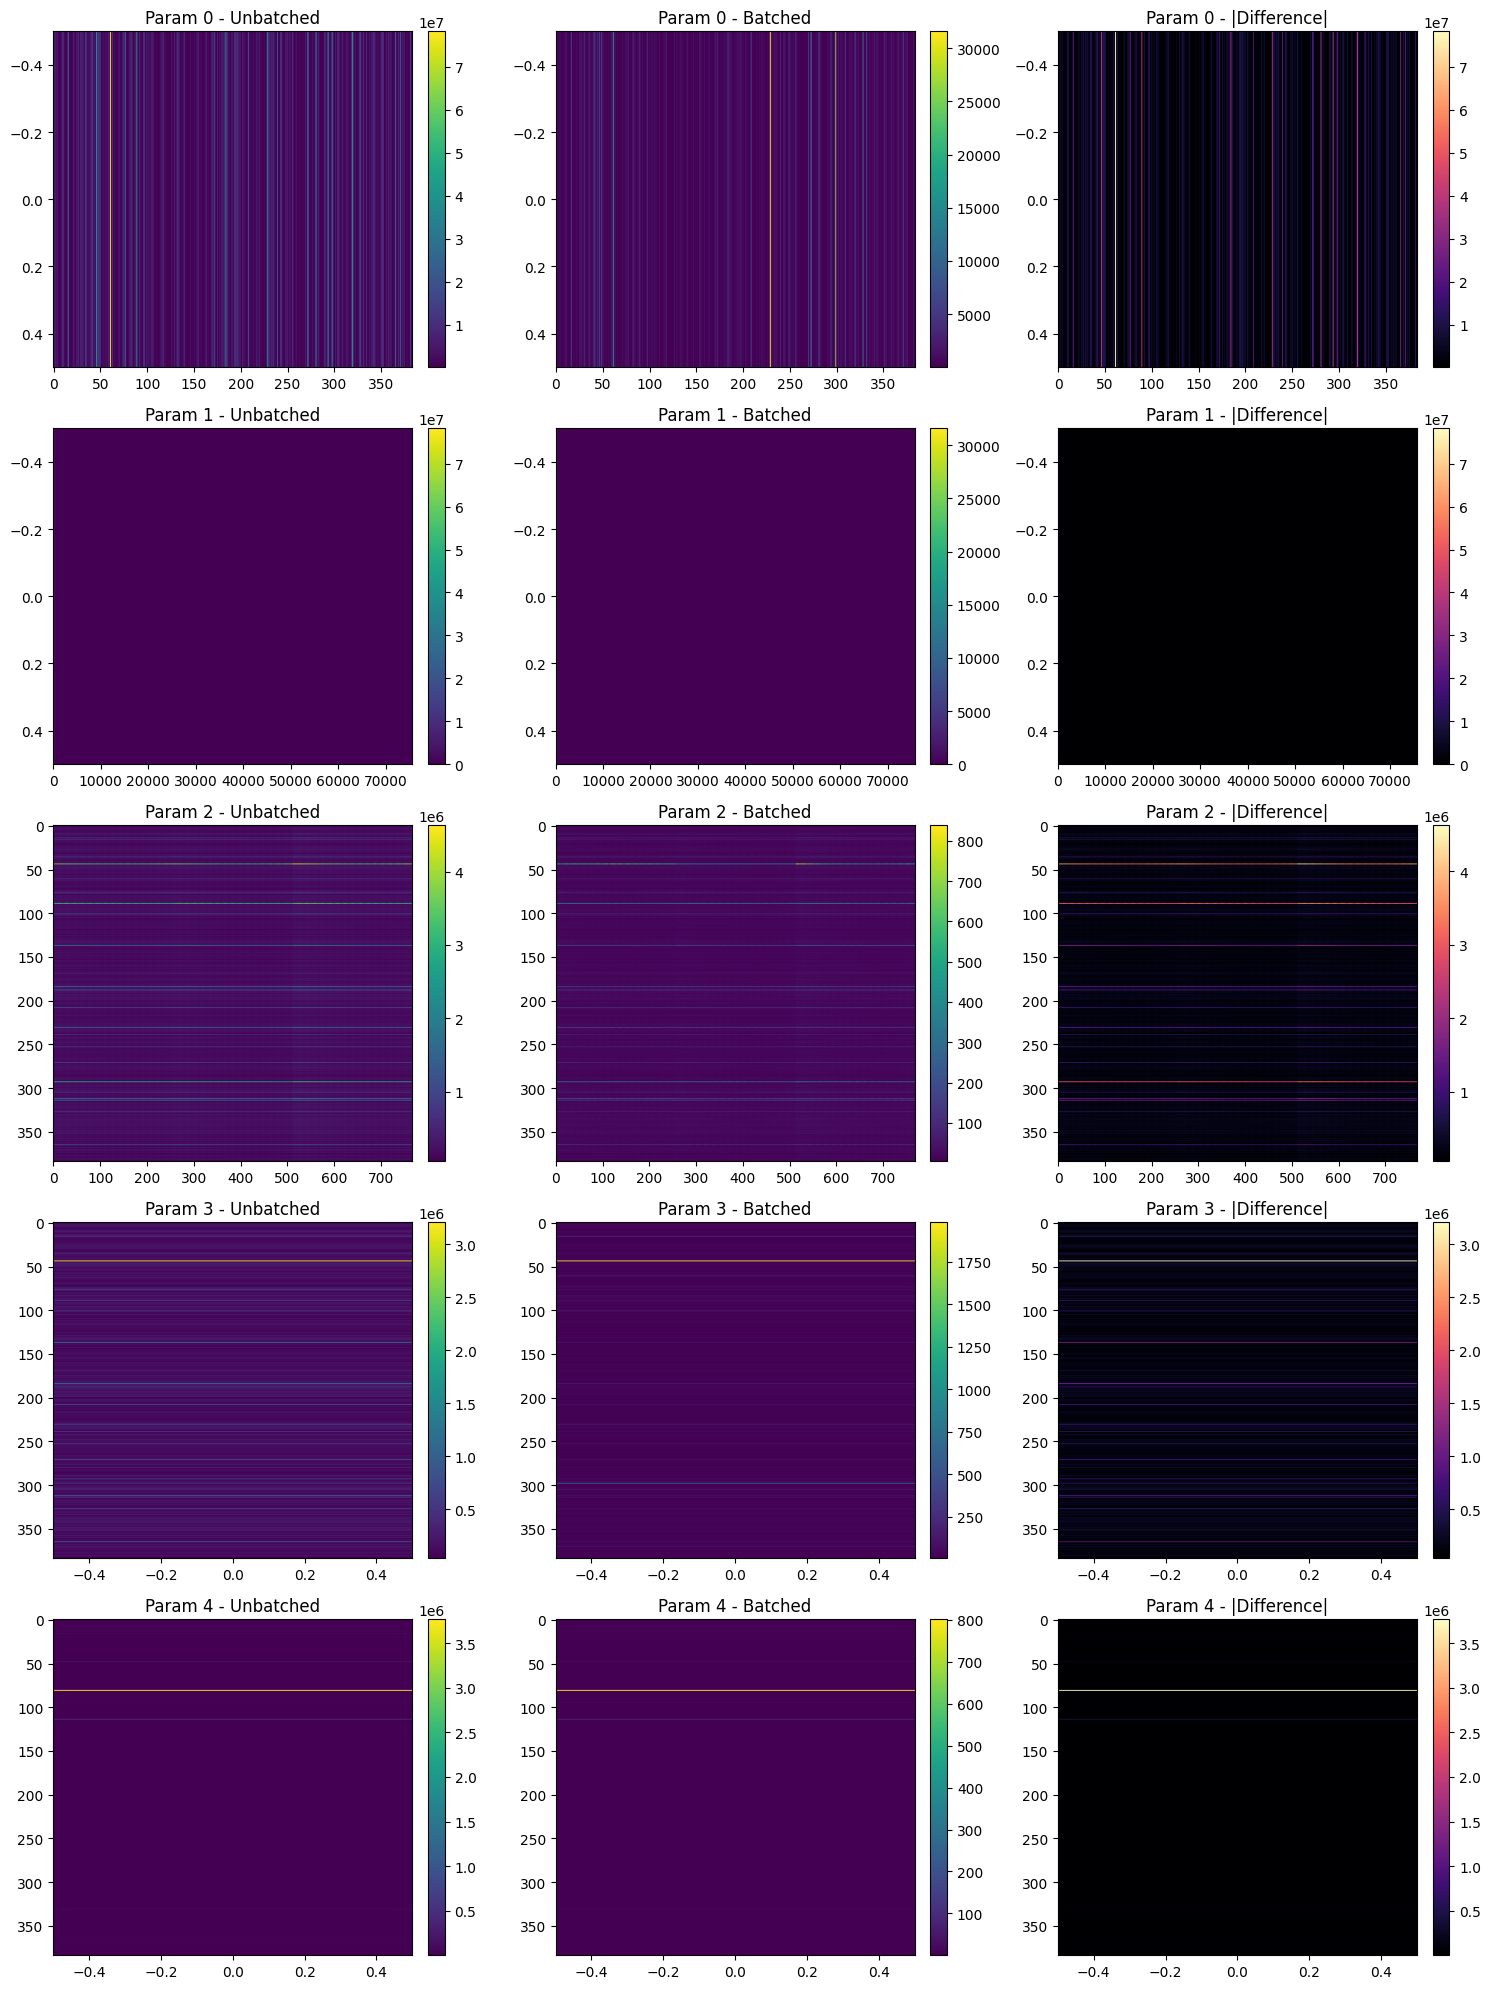

Done!


In [40]:
'''
TODO:
Batch normalization, probably. I think I read somewhere that the facebook model needs this. someone also needs to look up how to make good use of the model
    - Added normalization transform to images from facebook github // Gustav
Version control and checkpointing.
    - added version control, checkpoitning left //Gustav
    - Added checkpointing. Not tested yet //Gustav
    - Tested and fully implemented // Gustav
Testing and hyperparameter tuning. also model head architecture
    - Added very simple model head architecture
gradient mask TaLoS thing. Also expanding this to FL. This is a big one.
    - possibly implemented for single model case. needs testing
Plot accuracy and loss method in DinoFullModel
    - added // Gustav
Type hinting
    - added // Gustav

Questions:
    - Is the sharding supposed to work like this?
        - is the iid supposed to have a uniform distribution of labels
        - explain non-iid
    - Is there a better way to do addition and multiplication in FedAvg?
    - Facebook model head. Is it correct? Should the backend be static?
    - are the results reasonable?
    - Batch normalization?
    - The aldready implemented normalization?
'''

def FL_test():
    FL = FL_server(K, filepath="test_FLmodel").to(device)
    FL.FedAvg(split_train_dataloader_iid, 1, validate_dataloader=validate_dataloader, filepath="test_FLmodel")
    FL.test_model(test_dataloader)

def single_test():
    model = DinoFullModel().to(device)
    #for param in model.parameters():
    #    print(param.shape)
    model.load_model(filepath="test_model.pt")
    model.plot_performance()

    model.train_model(train_dataloader, validate_dataloader=validate_dataloader, filepath="test_model")
    model.plot_performance()
    print("Done!")


def finetune_test():
    model = DinoFullModel().to(device)
    #for param in model.parameters():
    #    print(param.shape)
    #model.plot_performance()
    model.epochs = 1
    model.finetune(train_dataloader, validate_dataloader=validate_dataloader, sparsity = 0.1)
    model.plot_score_heatmaps(show_difference=True)
    print("Done!")

def finetune_batch_test():
    model = DinoFullModel().to(device)
    model.epochs=0
    model.finetune(train_dataloader, validate_dataloader=validate_dataloader, sparsity = 0.1, use_both_scoring_methods=True)
    model.plot_score_heatmaps()
    print("Done!")
finetune_batch_test()
